In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Set plot style
sns.set_theme(style="whitegrid")

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Check data types, non-null counts, and memory usage
print("--- Dataset Info ---")
df.info()

# Summary statistics for numerical features
print("\n--- Numerical Summary Statistics ---")
display(df.describe())

# Summary statistics for categorical features
print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['O']))

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

--- Numerical Summary Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Categorical Summary Statistics ---


C:\Users\reeth\AppData\Local\Temp\ipykernel_24816\2996047877.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']))


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [3]:
# Check count of missing values per column
print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Median imputation for Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Mode imputation for Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop Cabin due to high missing rate
df = df.drop(columns=['Cabin'])

# Verify all missing values are resolved
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


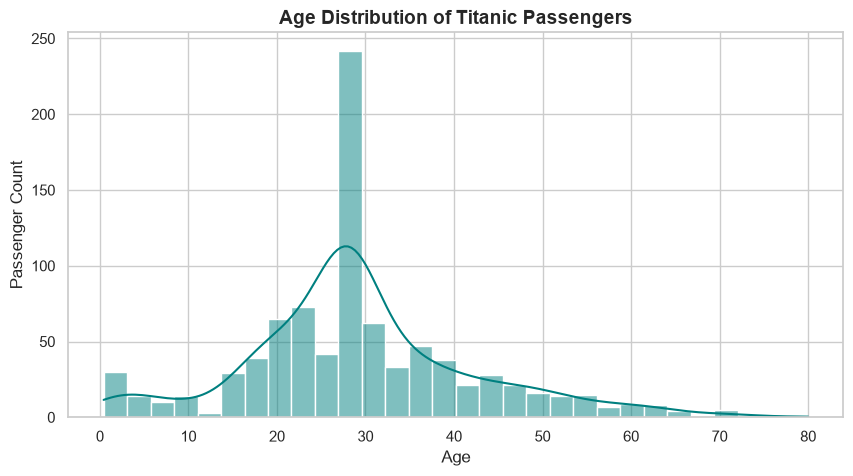

In [4]:
plt.figure(figsize=(10, 5))

# Plot histogram with Kernel Density Estimate (KDE)
sns.histplot(df['Age'], kde=True, bins=30, color='teal')

plt.title('Age Distribution of Titanic Passengers', fontsize=14, weight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.show()

In [5]:
# 1. Label Encoding on 'Sex'
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])
print(f"LabelEncoder mapping for Sex: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. One-Hot Encoding on 'Embarked'
ohe = OneHotEncoder(sparse_output=False, drop=None)
embarked_encoded = ohe.fit_transform(df[['Embarked']])
embarked_df = pd.DataFrame(embarked_encoded, columns=ohe.get_feature_names_out(['Embarked']))

# Concatenate one-hot encoded columns back to the DataFrame
df = pd.concat([df, embarked_df], axis=1)

# Drop redundant raw text columns
df_cleaned = df.drop(columns=['Sex', 'Embarked'])

df_cleaned.head()

LabelEncoder mapping for Sex: {'female': np.int64(0), 'male': np.int64(1)}


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_Encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0.0,0.0,1.0


In [6]:
output_file = "titanic_cleaned.csv"
df_cleaned.to_csv(output_file, index=False)

print(f"Cleaned dataset successfully exported as '{output_file}'.")

Cleaned dataset successfully exported as 'titanic_cleaned.csv'.
